In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


import ast
import concurrent.futures
import glob
import itertools
import joblib
import os
import pickle
import warnings
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator

import cvxpy as cp
import numpy as np
import pandas as pd
import polars as pl
import statsmodels.api as sm

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)


warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Read in all the npy files and concatenate into big parquet

In [2]:
lambda_exp = -4
stage2_beta_folder = "./stage2_betas_organized"
lambda_subfolder = f"lambda_exp={lambda_exp}"

results_subfolder = Path(f"./stage2_betas_organized/lambda_exp={lambda_exp}")

os.makedirs("./stage2_benchmark_results", exist_ok=True)

cutoff_list = list(range(57,1158))

In [3]:
results_subfolder

PosixPath('stage2_betas_organized/lambda_exp=-4')

In [4]:
# y_pred files are of form 
# stage2_y_pred_exp={}=cutoff={}_fips={}.npy
# Function to process a single file
def process_file(file_name):
    try:
        if file_name.endswith(".npy"):
            # Parse the file name to extract cutoff and fips
            parts = file_name.split('=')
            
            # Extract cutoff and fips values
            cutoff = int(parts[2].split('_')[0])  # The second part contains the cutoff
            fips = int(parts[3].split('.')[0])  # The third part contains fips (removing the .npy part)
    
            # Load the .npy file
            file_path = os.path.join(results_subfolder, file_name)
            entries = np.load(file_path)
    
            # Keep the entry with the larger absolute value (further from 0)
            stage2_r = entries[np.argmax(np.abs(entries))] - entries[np.argmin(np.abs(entries))]
    
            # Return the result as a tuple
            return cutoff, fips, stage2_r, entries
    except:
        return None

# Function to check if a file is valid
def is_valid_file(file_path):
    print(file_path.name)
    if file_path.is_file() and file_path.name.startswith("stage2_y_pred") and file_path.suffix == ".npy":
        return file_path
    return None

# Function to gather valid filenames in parallel
def get_valid_filenames():
    # Use rglob to find all .npy files and filter in parallel
    with ThreadPoolExecutor() as executor:
        # Use executor.map to check for valid files in parallel
        valid_files = executor.map(is_valid_file, results_subfolder.rglob("*.npy"))

    # Filter valid filenames
    valid_filenames = [file_path for file_path in valid_files if file_path is not None]
    return valid_filenames



In [5]:

def process_cutoff(cutoff):
    tqdm.write(f"Processing cutoff={cutoff}")
    data = []
    cutoff_folder = results_subfolder / str(cutoff)  # Define the path to the cutoff folder
    
    # Check if the cutoff folder exists
    if cutoff_folder.is_dir():
        # Iterate through all .npy files in the cutoff folder
        for file in cutoff_folder.glob(f"stage2_y_pred_exp={lambda_exp}_cutoff=*_fips=*.npy"):
            # Load the .npy file
            try:
                entries = np.load(file)
                
                # Check if the entries have at least 2 values
                if len(entries) >= 2:
                    # Extract the FIPS from the filename
                    fips = int(file.name.split("fips=")[1].split(".npy")[0])  # Extract FIPS from filename
                    stage2_r_pred = entries[1]  # Get the second entry
    
                    week_growth = stage2_r_pred * 7
                    
                    # Append to the data list
                    data.append({"cutoff": cutoff, "fips": fips, "stage2_r_pred": stage2_r_pred, "week_growth": week_growth})
            except Exception as e:
                tqdm.write(f"Error processing file {file}: {e}")
    
    return data



In [6]:
stage2_df_fname = f"./stage2_benchmark_results/stage2_predictions_week_growth_lambda_exp={lambda_exp}.parquet"

if not os.path.exists(stage2_df_fname):
    # Use ThreadPoolExecutor to process each cutoff in parallel
    all_data = []
    with ProcessPoolExecutor() as executor:
        futures = {executor.submit(process_cutoff, cutoff): cutoff for cutoff in cutoff_list}
        
        # Collect results as they complete
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing Cutoffs"):
            data = future.result()
            all_data.extend(data)
    
    # Create a Polars DataFrame from the collected data
    df = pl.DataFrame(all_data).sort(["cutoff","fips"])

    df.write_parquet(stage2_df_fname)
else:
    df = pl.read_parquet(stage2_df_fname).sort(["cutoff","fips"])

### Load benchmark dataframe

In [7]:
benchmark_Imputed_TLGRF_dataset_fname = "../generate_benchmark_TLGRF_dataset/benchmark_Imputed_TLGRF_dataset.csv"
benchmark_Imputed_TLGRF_dataset = pl.read_csv(benchmark_Imputed_TLGRF_dataset_fname).sort(["days_from_start", "fips"])


In [8]:
small_benchmark = benchmark_Imputed_TLGRF_dataset.filter(pl.col("days_from_start").is_in(set(cutoff_list)))

In [9]:
small_benchmark

fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
i64,i64,f64,f64,str,str,str,f64,f64,f64,f64
2020,57,null,null,"""Anchorage""","""Alaska""","""2020-03-18""",1.571429,0.982613,2.53935,null
4013,57,null,null,"""Maricopa""","""Arizona""","""2020-03-18""",5.0,1.808289,4.706566,null
4019,57,null,null,"""Pima""","""Arizona""","""2020-03-18""",2.857143,1.375522,3.170286,null
4021,57,null,null,"""Pinal""","""Arizona""","""2020-03-18""",5.428571,1.876188,2.839078,null
5069,57,null,null,"""Jefferson""","""Arkansas""","""2020-03-18""",4.142857,1.656867,3.049273,null
…,…,…,…,…,…,…,…,…,…,…
69120,1157,null,null,"""Tinian""","""Northern Mariana Islands""","""2023-03-23""",0.0,0.09531,null,null
78010,1157,1219.458767,-0.0557,"""St. Croix""","""Virgin Islands""","""2023-03-23""",41.571429,3.75353,null,3.363633
78020,1157,null,null,"""St. John""","""Virgin Islands""","""2023-03-23""",6.285714,1.999548,null,null


In [10]:
small_benchmark_w_STAGE2 = small_benchmark.join(df, right_on=["cutoff","fips"], left_on=["days_from_start","fips"])
small_benchmark_w_STAGE2 = small_benchmark_w_STAGE2.with_columns((pl.col("log_rolled_cases") + pl.col("week_growth")).alias("stage2_predicted_log_rolled_cases"))

In [11]:
small_benchmark_w_STAGE2

fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases,stage2_r_pred,week_growth,stage2_predicted_log_rolled_cases
i64,i64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
6001,57,35.269573,0.217423,"""Alameda""","""California""","""2020-03-18""",38.0,3.666122,4.723207,5.188086,0.025376,0.177631,3.843753
6013,57,37.901876,0.235264,"""Contra Costa""","""California""","""2020-03-18""",27.571429,3.355901,4.210433,5.002749,0.041389,0.289726,3.645627
6037,57,34.057865,0.249453,"""Los Angeles""","""California""","""2020-03-18""",87.857143,4.488155,6.153553,6.234323,0.070111,0.490778,4.978932
6067,57,37.827954,0.235484,"""Sacramento""","""California""","""2020-03-18""",28.142857,3.375635,4.212551,5.024025,0.036319,0.254232,3.629868
6073,57,37.413552,0.246486,"""San Diego""","""California""","""2020-03-18""",36.428571,3.625103,5.276437,5.350504,0.084972,0.594807,4.21991
…,…,…,…,…,…,…,…,…,…,…,…,…,…
56039,1157,1607.407159,-0.006716,"""Teton""","""Wyoming""","""2023-03-23""",21.0,3.095578,null,3.048568,-0.000106,-0.00074,3.094838
56041,1157,1198.145894,-0.075309,"""Uinta""","""Wyoming""","""2023-03-23""",30.857143,3.464396,null,2.937236,-0.022314,-0.156196,3.3082
78010,1157,1219.458767,-0.0557,"""St. Croix""","""Virgin Islands""","""2023-03-23""",41.571429,3.75353,null,3.363633,-0.015294,-0.107055,3.646475


### Metrics

In [12]:
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))

rmse_stage2_func = lambda x: np.sqrt(np.nanmean((x["stage2_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_stage2_func = lambda x: np.nanmean(np.abs(x["stage2_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))

log_20 = np.log(20 + 1.1)

filtered_small_benchmark_w_STAGE2 = small_benchmark_w_STAGE2.to_pandas()
filtered_small_benchmark_w_STAGE2["date"] = pd.to_datetime(filtered_small_benchmark_w_STAGE2["date"])
filtered_small_benchmark_w_STAGE2 = filtered_small_benchmark_w_STAGE2[filtered_small_benchmark_w_STAGE2["log_rolled_cases"] >= log_20]
filtered_small_benchmark_w_STAGE2 = filtered_small_benchmark_w_STAGE2[filtered_small_benchmark_w_STAGE2["date"] <= "2022-12-31"]


#TLGRF
RMSE_TLGRF = filtered_small_benchmark_w_STAGE2.groupby("date").apply(rmse_TLGRF_func)
MAE_TLGRF = filtered_small_benchmark_w_STAGE2.groupby("date").apply(mae_TLGRF_func)

# stage2
RMSE_stage2 = filtered_small_benchmark_w_STAGE2.groupby("date").apply(rmse_stage2_func)
MAE_stage2 = filtered_small_benchmark_w_STAGE2.groupby("date").apply(mae_stage2_func)


In [13]:
combined_daily_metrics_df = pd.DataFrame()
combined_daily_metrics_df["MAE TLGRF"] = MAE_TLGRF
combined_daily_metrics_df["RMSE TLGRF"] = RMSE_TLGRF

combined_daily_metrics_df["MAE stage2"] = MAE_stage2
combined_daily_metrics_df["RMSE stage2"] = RMSE_stage2


In [14]:
combined_daily_metrics_df.to_csv(f"./stage2_benchmark_results/combined_daily_metrics_df_stage2_lambda_exp={lambda_exp}.csv")
combined_daily_metrics_df

,MAE TLGRF,RMSE TLGRF,MAE stage2,RMSE stage2
date,,,,
2020-03-18,0.496249,0.588465,1.186710,1.310959
2020-03-19,0.385541,0.441789,1.177335,1.255045
2020-03-20,0.380631,0.466845,1.176448,1.239981
2020-03-21,0.414085,0.505139,1.133135,1.180858
2020-03-22,0.497879,0.565417,1.079536,1.124260
...,...,...,...,...
2022-12-27,0.200337,0.264837,0.145437,0.197043
2022-12-28,0.130893,0.181575,0.126930,0.176201
2022-12-29,0.113211,0.175066,0.114650,0.160247


In [15]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["MAE"] = [MAE_stage2.median(), MAE_TLGRF.median()]
metrics_comparison_df["RMSE"] = [RMSE_stage2.median(), RMSE_TLGRF.median()]
metrics_comparison_df.index = ["Stage 2", "TLGRF"]



metrics_comparison_df.to_csv(f"./stage2_benchmark_results/metrics_comparison_stage2_lambda_exp={lambda_exp}.csv")

In [16]:
metrics_comparison_df

,MAE,RMSE
Stage 2,0.167879,0.229799
TLGRF,0.126514,0.194737


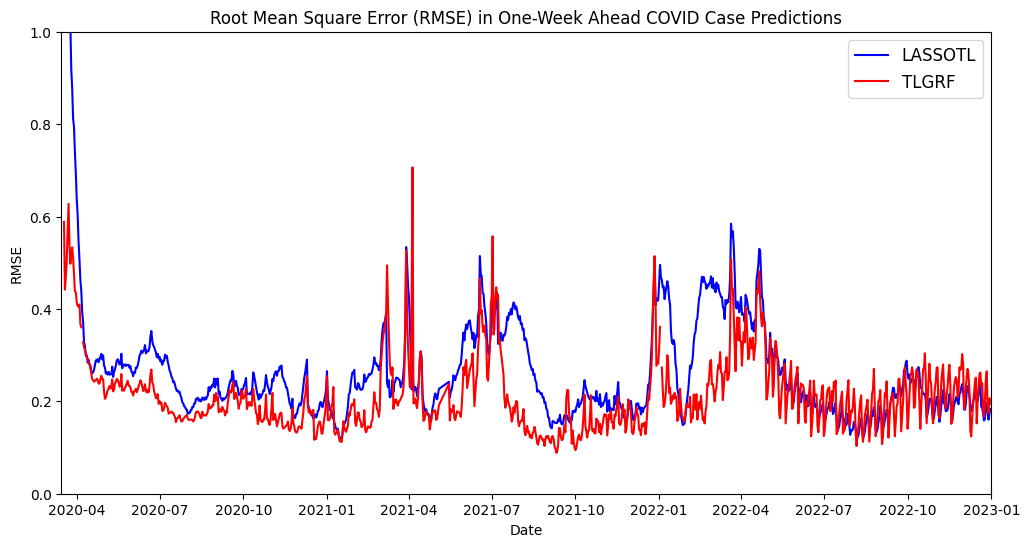

In [17]:
plt.figure(figsize=(12,6))

plt.plot(RMSE_stage2, label="LASSOTL", color="blue")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")



plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig(f"./stage2_benchmark_results/Benchmark_Stage2_lambda_exp={lambda_exp}_rmse.png")
plt.show()


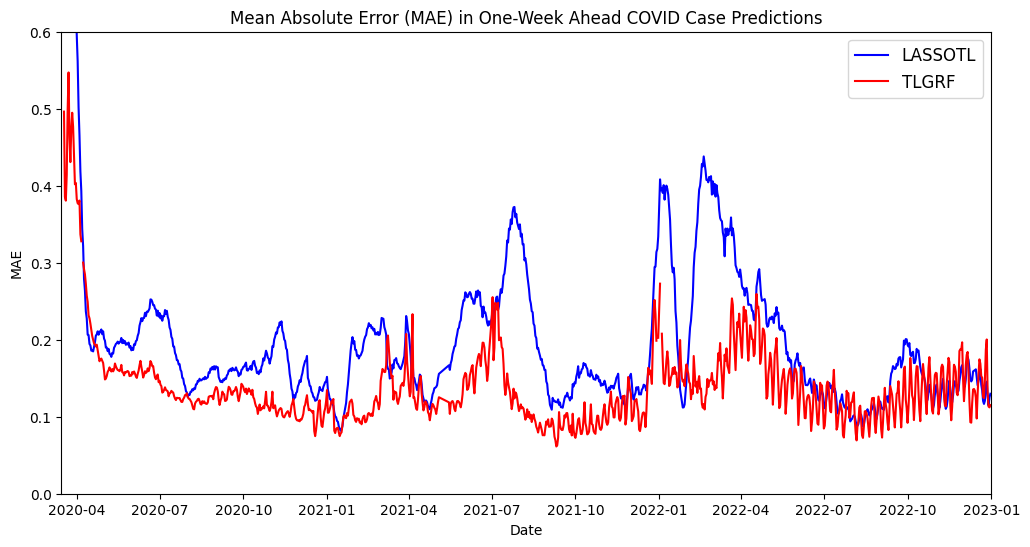

In [18]:
plt.figure(figsize=(12,6))

plt.plot(MAE_stage2, label="LASSOTL", color="blue")
plt.plot(MAE_TLGRF, label="TLGRF", color="red")



plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig(f"./stage2_benchmark_results/Benchmark_Stage2_lambda_exp={lambda_exp}_mae.png")

plt.show()


In [19]:
RMSE_stage2.index

DatetimeIndex(['2020-03-18', '2020-03-19', '2020-03-20', '2020-03-21',
               '2020-03-22', '2020-03-23', '2020-03-24', '2020-03-25',
               '2020-03-26', '2020-03-27',
               ...
               '2022-12-22', '2022-12-23', '2022-12-24', '2022-12-25',
               '2022-12-26', '2022-12-27', '2022-12-28', '2022-12-29',
               '2022-12-30', '2022-12-31'],
              dtype='datetime64[ns]', name='date', length=1008, freq=None)